**Goal.** Convert spatiotemporal tensors into **monthly graph shards** for fast training.

**What this notebook does**
1. Loads the static graph `.npz` and verifies node count `N`.
2. For each month, gathers `[T, C, N]` values and slices supervised windows.
3. Writes `graph_YYYY-MM.pt` with the following keys:

   - `values` : **[T, C, N]** (float16/float32)

   - `Tin`, `Tout` : window sizes used when preparing samples

   - `stride` : step between sample starts (usually 1)

   - `sample_starts` : vector of starting indices

   - `channel_names` : list of channel identifiers

**Checks**
- Confirm `N` in shards matches `N` in the static graph.
- Persist **channel order** that your models expect.
- Optionally down‑cast to `float16` to reduce disk size.

In [1]:
from __future__ import annotations
import os
from pathlib import Path
from typing import Dict, List, Tuple, Optional
import numpy as np
import xarray as xr
import torch, json, hashlib, datetime as dt

In [ ]:
# ---------- Paths (edit as needed) ----------
RAW_ROOTS = {
    "1deg":  Path("./data/raw/1deg"),
    "05deg": Path("./data/raw/05deg"),
    "025deg":Path("./data/raw/025deg"),
}
STATS_PATHS = {
    "1deg":  Path("./data/stats/stats_1deg_1980_2013.npz"),
    "05deg": Path("./data/stats/stats_05deg_1980_2013.npz"),
    "025deg":Path("./data/stats/stats_025deg_1980_2013.npz"),
}
STATIC_GRAPH_NPZ = Path("./data/graph/graph_static_from_stats_vgeo_aligned.npz")
MESH_NPZ         = Path("./data/mesh/multiscale_jigsaw_ll.npz")

OUT_ROOT = Path("./data/shards_graph")

AREA = (75.0, -50.0, 30.0, 20.0)  # (lat_max, lon_min, lat_min, lon_max)

TIN   = 2
TOUT  = 4

STRIDE= 1

WRITE_DTYPE = "float16"  # 'float16' або 'float32'

In [ ]:
# ---------- Helpers ----------
def find_time_name(ds: xr.Dataset) -> str:
    for n in ("valid_time","time"):
        if n in ds.dims or n in ds.coords:
            return n
    raise KeyError("time coordinate not found")

def _ensure_monotonic_lonlat(ds: xr.Dataset, lon_name="lon", lat_name="lat") -> xr.Dataset:
    # wrap lon to [-180, 180)
    if float(ds[lon_name].max()) > 180.0:
        ds = ds.assign_coords({lon_name: ((ds[lon_name] + 180) % 360) - 180})
    # sort axes ascending
    if not np.all(np.diff(ds[lon_name].values) > 0):
        ds = ds.sortby(lon_name)
    if not np.all(np.diff(ds[lat_name].values) > 0):
        ds = ds.sortby(lat_name)
    return ds

def norm_names_surface(ds: xr.Dataset) -> xr.Dataset:
    ren = {}
    if "longitude" in ds.dims or "longitude" in ds.coords: ren["longitude"] = "lon"
    if "latitude"  in ds.dims or "latitude"  in ds.coords: ren["latitude"]  = "lat"
    tname = find_time_name(ds)
    if tname != "valid_time": ren[tname] = "valid_time"
    if ren: ds = ds.rename(ren)
    ds = _ensure_monotonic_lonlat(ds, "lon", "lat")
    return ds

def norm_names_pressure(ds: xr.Dataset) -> xr.Dataset:
    lon_name = "longitude" if ("longitude" in ds.coords or "longitude" in ds.dims) else "lon"
    lat_name = "latitude"  if ("latitude"  in ds.coords or "latitude"  in ds.dims) else "lat"
    time_name= "valid_time" if ("valid_time" in ds.coords or "valid_time" in ds.dims) else ("time" if ("time" in ds.coords or "time" in ds.dims) else None)
    if time_name is None: raise KeyError("time coord not found in pressure_levels dataset")

    cand_levs = [n for n in ("pressure_level","isobaricInhPa","level","lev") if (n in ds.coords or n in ds.dims)]
    if not cand_levs: raise KeyError("pressure level coord not found")
    lev_name = cand_levs[0]

    ren = {}
    if lon_name != "lon": ren[lon_name] = "lon"
    if lat_name != "lat": ren[lat_name] = "lat"
    if time_name != "valid_time": ren[time_name] = "valid_time"
    if lev_name  != "pressure_level": ren[lev_name]  = "pressure_level"
    if ren: ds = ds.rename(ren)

    if ("pressure_level" in ds.coords) and ("pressure_level" not in ds.dims):
        target_len = ds["pressure_level"].sizes.get("pressure_level", ds["pressure_level"].size)
        cand_dims = [d for d in ds.dims if ds.sizes[d] == target_len]
        if cand_dims:
            ds = ds.swap_dims({cand_dims[0]: "pressure_level"})
        else:
            ds = ds.set_index({"pressure_level": "pressure_level"})

    ds = _ensure_monotonic_lonlat(ds, "lon", "lat")
    return ds

def open_surface_month(root: Path, y: int, m: int) -> Optional[xr.Dataset]:
    f1 = root/"surface"/f"surface_{y}_{m:02d}.nc"
    f2 = root/"surface"/f"surface_p_{y}_{m:02d}.nc"
    if (not f1.exists()) and (not f2.exists()):
        return None
    ds = xr.open_dataset(f1) if f1.exists() else None
    if f2.exists():
        dsp = xr.open_dataset(f2)
        ds = dsp if ds is None else xr.merge([ds, dsp], compat="override", join="outer")
    ds = norm_names_surface(ds)
    return ds

def open_pressure_month(root: Path, y: int, m: int) -> Optional[xr.Dataset]:
    f = root/"pressure_levels"/f"pressure_{y}_{m:02d}.nc"
    if not f.exists(): return None
    ds = xr.open_dataset(f)
    ds = norm_names_pressure(ds)
    return ds

def slice_to_area(ds: xr.Dataset, area=AREA) -> xr.Dataset:
    lat_max, lon_min, lat_min, lon_max = area
    lat_asc = bool(ds["lat"][0] < ds["lat"][-1])
    lon_asc = bool(ds["lon"][0] < ds["lon"][-1])
    lat_slice = slice(lat_min, lat_max) if lat_asc else slice(lat_max, lat_min)
    lon_slice = slice(lon_min, lon_max) if lon_asc else slice(lon_max, lon_min)
    return ds.sel(lon=lon_slice, lat=lat_slice)

def tp_log(arr: xr.DataArray) -> xr.DataArray:
    x = xr.where(arr < 0, 0, arr).astype(np.float32)
    return np.log1p(x)

# ---------- Stats ----------
class StatsLookup:
    def __init__(self, npz_path: Path):
        z = np.load(npz_path, allow_pickle=True)
        order = list(z["order"])
        if len(order) and isinstance(order[0], (bytes, np.bytes_)):
            order = [o.decode("utf-8") for o in order]
        self.order = order
        self.idx = {n:i for i,n in enumerate(order)}
        self.mu  = np.asarray(z["mean"], dtype=np.float64)
        self.sd  = np.asarray(z["std"],  dtype=np.float64)
        self.sd[self.sd < 1e-6] = 1e-6

    def ns_by_name(self, name: str, arr: np.ndarray) -> np.ndarray:
        i = self.idx[name]
        return ((arr - self.mu[i]) / self.sd[i]).astype(np.float32, copy=False)

# ---------- Mesh & zones (from static graph file) ----------
def load_static_graph(path: Path):
    npz = np.load(path, allow_pickle=True)
    N_mesh = int(npz["N_mesh"])
    L = int(npz["L"])
    lon = np.array(npz["coord_lon"], dtype=np.float32)
    lat = np.array(npz["coord_lat"], dtype=np.float32)
    level_offsets = np.array(npz["level_offsets"], dtype=np.int32)
    levels = [str(x) for x in npz["levels"]]
    mesh_hash = (npz["mesh_hash"].item().decode() if isinstance(npz["mesh_hash"].item(), (bytes, np.bytes_)) else str(npz["mesh_hash"].item()))
    zone_id_full = np.array(npz["zone_id"], dtype=np.int8)  # repeated per level
    # звужуємо до базового рівня:
    zone_mesh = zone_id_full[:N_mesh]
    return {"N_mesh":N_mesh,"L":L,"lon":lon,"lat":lat,"levels":levels,
            "level_offsets":level_offsets,"mesh_hash":mesh_hash,"zone_mesh":zone_mesh}

# ---------- Bilinear precompute & apply ----------
def _precompute_bilinear_indices(lat1d: np.ndarray, lon1d: np.ndarray,
                                 pts_lon: np.ndarray, pts_lat: np.ndarray):
    lat_ax = np.asarray(lat1d, dtype=np.float32)
    lon_ax = np.asarray(lon1d, dtype=np.float32)
    if lat_ax[1] < lat_ax[0]:
        lat_ax = lat_ax[::-1]; flip_lat = True
    else:
        flip_lat = False
    if lon_ax[1] < lon_ax[0]:
        lon_ax = lon_ax[::-1]; flip_lon = True
    else:
        flip_lon = False

    def locate(ax, x):
        x = np.clip(x, ax[0], ax[-1])
        idx = np.searchsorted(ax, x) - 1
        idx = np.clip(idx, 0, len(ax)-2)
        x0 = ax[idx]; x1 = ax[idx+1]
        t  = (x - x0) / (x1 - x0 + 1e-12)
        return idx.astype(np.int32), (idx+1).astype(np.int32), t.astype(np.float32)

    i0, i1, ty = locate(lat_ax, pts_lat.astype(np.float32))
    j0, j1, tx = locate(lon_ax, pts_lon.astype(np.float32))

    return {
        "i0":i0, "i1":i1, "j0":j0, "j1":j1, "tx":tx, "ty":ty,
        "flip_lat":flip_lat, "flip_lon":flip_lon
    }

def _bilinear_apply_2d(field_2d: np.ndarray, pre: Dict) -> np.ndarray:
    """field_2d: [H,W] → [N_pts]"""
    g = field_2d
    if pre["flip_lat"]: g = g[::-1, :]
    if pre["flip_lon"]: g = g[:, ::-1]
    i0,i1,j0,j1,tx,ty = pre["i0"], pre["i1"], pre["j0"], pre["j1"], pre["tx"], pre["ty"]
    v00 = g[i0, j0]; v01 = g[i0, j1]; v10 = g[i1, j0]; v11 = g[i1, j1]
    v0  = v00*(1-tx) + v01*tx
    v1  = v10*(1-tx) + v11*tx
    return (v0*(1-ty) + v1*ty).astype(np.float32, copy=False)

# ---------- Channel order & parsing ----------
def build_channels_from_stats_order(order: List[str]):
    """
    order (from stats npz):
      ['t2m','d2m','msl','u10','v10','tp_log',
       't_850','u_850','v_850','r_850','z_850',
       't_500', ... 'z_300']
    Returns:
      channel_names: ['t2m@sfc', ..., 'z@300']
      levels:        ['sfc','850','500','300']
      vars_by_level: dict
    """
    sfc_vars = []
    lev_map: Dict[str,List[str]] = {}
    for name in order:
        if "_" in name and name.split("_")[-1].isdigit():
            base, lev = name.rsplit("_", 1)
            lev_map.setdefault(lev, []).append(base)
        else:
            sfc_vars.append(name)
    levels = ["sfc"] + list(lev_map.keys())
    # канал-імена
    chan = [f"{v}@sfc" for v in sfc_vars]
    for lev, vars_ in lev_map.items():
        chan.extend([f"{v}@{lev}" for v in vars_])
    vars_by_level = {"sfc": sfc_vars}
    vars_by_level.update({lev: vars_ for lev, vars_ in lev_map.items()})
    return chan, levels, vars_by_level

def stats_key_for_channel(ch: str) -> str:
    # 't2m@sfc' -> 't2m'; 't@850' -> 't_850', etc.
    var, lev = ch.split("@")
    return var if lev == "sfc" else f"{var}_{lev}"

# ---------- Misc ----------
def sha256_bytes(a: np.ndarray) -> str:
    h = hashlib.sha256()
    h.update(np.ascontiguousarray(a).data)
    return h.hexdigest()

def iters_per_epoch(n_samples: int, global_bsz: int) -> int:
    import math
    return int(np.ceil(n_samples / max(1, global_bsz)))

In [5]:
def build_graph_month_shard(year: int, month: int,
                            static_graph_npz: Path = STATIC_GRAPH_NPZ,
                            raw_roots: Dict[str,Path] = RAW_ROOTS,
                            stats_paths: Dict[str,Path] = STATS_PATHS,
                            tin: int = TIN, tout: int = TOUT, stride: int = STRIDE,
                            write_dtype: str = WRITE_DTYPE,
                            out_root: Path = OUT_ROOT) -> Path:
    SG = load_static_graph(static_graph_npz)
    N_mesh = SG["N_mesh"]; L = SG["L"]; lon_nodes = SG["lon"]; lat_nodes = SG["lat"]
    zone_mesh = SG["zone_mesh"]; mesh_hash = SG["mesh_hash"]

    # open all scales for the month
    dsets = {}; times_scaled = {}
    for tag in ("025deg","05deg","1deg"):
        root = raw_roots[tag]
        ds_s = open_surface_month(root, year, month)
        ds_p = open_pressure_month(root, year, month)
        if ds_s is None or ds_p is None:
            raise FileNotFoundError(f"[{tag}] missing surface or pressure for {year}-{month:02d}")
        ds_s = slice_to_area(ds_s, AREA); ds_p = slice_to_area(ds_p, AREA)
        t_s = np.asarray(ds_s[find_time_name(ds_s)].values).astype("datetime64[s]")
        t_p = np.asarray(ds_p[find_time_name(ds_p)].values).astype("datetime64[s]")
        t_scale = np.intersect1d(t_s, t_p)
        if t_scale.size == 0:
            raise RuntimeError(f"[{tag}] no common timestamps for {year}-{month:02d}")
        dsets[tag] = {"s": ds_s.sel(valid_time=t_scale), "p": ds_p.sel(valid_time=t_scale)}
        times_scaled[tag] = t_scale

    # common timeline across scales
    times_common = times_scaled["1deg"]
    times_common = np.intersect1d(times_common, times_scaled["05deg"])
    times_common = np.intersect1d(times_common, times_scaled["025deg"])
    if times_common.size == 0:
        raise RuntimeError(f"No common timestamps across scales for {year}-{month:02d}")
    for tag in dsets:
        dsets[tag]["s"] = dsets[tag]["s"].sel(valid_time=times_common)
        dsets[tag]["p"] = dsets[tag]["p"].sel(valid_time=times_common)

    t_i64 = times_common.astype("int64")
    diffs = np.unique(np.diff(t_i64))
    if diffs.size == 0:
        raise RuntimeError("Not enough timestamps to determine dt_seconds")
    dt_seconds = int(diffs[0])
    if not np.all(diffs == dt_seconds):
        print(f"⚠️ non-uniform dt detected: {diffs} → using {dt_seconds}s")
    # 6h check
    if dt_seconds != 6*3600:
        print(f"⚠️ expected 6h data, but dt_seconds={dt_seconds}. Proceeding anyway.")
    t0_unix = int(t_i64[0]); T = int(times_common.size)

    # stats per scale
    ST = {tag: StatsLookup(stats_paths[tag]) for tag in ("1deg","05deg","025deg")}
    # channel order from 1deg master
    order_1 = ST["1deg"].order
    channel_names, levels_parsed, vars_by_level = build_channels_from_stats_order(order_1)
    C = len(channel_names)

    idx_roi   = np.where(zone_mesh == 0)[0]
    idx_ring  = np.where(zone_mesh == 1)[0]
    idx_outer = np.where(zone_mesh == 2)[0]

    # precompute bilinear for each scale and zone
    pre = {}
    for tag in ("025deg","05deg","1deg"):
        s = dsets[tag]["s"]
        lat1d = s["lat"].values.astype(np.float32)
        lon1d = s["lon"].values.astype(np.float32)
        pre[tag] = {}
        if idx_roi.size:   pre[tag]["roi"]   = _precompute_bilinear_indices(lat1d, lon1d, lon_nodes[idx_roi],   lat_nodes[idx_roi])
        if idx_ring.size:  pre[tag]["ring"]  = _precompute_bilinear_indices(lat1d, lon1d, lon_nodes[idx_ring],  lat_nodes[idx_ring])
        if idx_outer.size: pre[tag]["outer"] = _precompute_bilinear_indices(lat1d, lon1d, lon_nodes[idx_outer], lat_nodes[idx_outer])

    dtype_np = np.float16 if write_dtype == "float16" else np.float32
    values = np.empty((T, C, N_mesh), dtype=dtype_np)

    SURF_MAP = {"t2m":"t2m", "d2m":"d2m", "msl":"msl", "u10":"u10", "v10":"v10", "tp_log":"tp"}
    def get_surface_field(tag: str, var_short: str) -> np.ndarray:
        ds = dsets[tag]["s"]
        if var_short == "tp_log":
            arr = tp_log(ds["tp"]).values.astype(np.float32)
        else:
            arr = ds[SURF_MAP[var_short]].values.astype(np.float32)
        return arr
    def get_pressure_field(tag: str, base: str, lev: str) -> np.ndarray:
        ds = dsets[tag]["p"]
        lev_i = int(lev)
        return ds[base].sel(pressure_level=lev_i, method="nearest").values.astype(np.float32)

    for ci, ch in enumerate(channel_names):
        skey = stats_key_for_channel(ch)
        if "@sfc" in ch:
            base = ch.split("@")[0]
            f_roi, f_ring, f_outer = get_surface_field("025deg", base), get_surface_field("05deg", base), get_surface_field("1deg", base)
        else:
            base, lev = ch.split("@")
            f_roi, f_ring, f_outer = get_pressure_field("025deg", base, lev), get_pressure_field("05deg", base, lev), get_pressure_field("1deg", base, lev)

        out_ch = np.full((T, N_mesh), np.nan, dtype=np.float32)
        if idx_roi.size:
            pre_roi = pre["025deg"]["roi"]
            for t in range(T):
                vals = _bilinear_apply_2d(f_roi[t], pre_roi)
                out_ch[t, idx_roi] = ST["025deg"].ns_by_name(skey, vals)
        if idx_ring.size:
            pre_ring = pre["05deg"]["ring"]
            for t in range(T):
                vals = _bilinear_apply_2d(f_ring[t], pre_ring)
                out_ch[t, idx_ring] = ST["05deg"].ns_by_name(skey, vals)
        if idx_outer.size:
            pre_outer = pre["1deg"]["outer"]
            for t in range(T):
                vals = _bilinear_apply_2d(f_outer[t], pre_outer)
                out_ch[t, idx_outer] = ST["1deg"].ns_by_name(skey, vals)

        values[:, ci, :] = out_ch.astype(dtype_np, copy=False)

    # sample index windows: Tin=2, Tout=1, stride=1 → [t[s], t[s+1]] -> t[s+2]
    max_start = T - (tin + tout)
    sample_starts = np.arange(0, max(0, max_start) + 1, stride, dtype=np.int32)
    N_samples = int(sample_starts.size)

    data_sha256 = sha256_bytes(values.view(np.uint8))
    levels_hash = hashlib.sha256("\n".join(levels_parsed).encode("utf-8")).hexdigest()
    vars_hash   = hashlib.sha256(json.dumps(vars_by_level, sort_keys=True).encode("utf-8")).hexdigest()
    channel_names_json = json.dumps(channel_names, ensure_ascii=False)
    vars_by_level_json = json.dumps(vars_by_level, ensure_ascii=False, sort_keys=True)

    out_root = Path(out_root); out_root.mkdir(parents=True, exist_ok=True)
    month_id = f"{year:04d}-{month:02d}"
    out_path = out_root / f"graph_{month_id}.pt"

    shard = {
        "values": torch.from_numpy(values),  # [T, C, N_mesh]
        "t0_unix":    torch.tensor(t0_unix, dtype=torch.int64),
        "dt_seconds": torch.tensor(dt_seconds, dtype=torch.int32),
        "T":          torch.tensor(T, dtype=torch.int32),
        "Tin":        torch.tensor(tin, dtype=torch.int16),
        "Tout":       torch.tensor(tout, dtype=torch.int16),
        "stride":     torch.tensor(stride, dtype=torch.int16),
        "sample_starts": torch.from_numpy(sample_starts),
        "N_samples":  torch.tensor(N_samples, dtype=torch.int32),

        "month_id":   month_id,
        "N_mesh":     torch.tensor(N_mesh, dtype=torch.int32),
        "L":          torch.tensor(L, dtype=torch.int16),
        "level_offsets": torch.from_numpy(SG["level_offsets"]),
        "levels":     levels_parsed,
        "vars_by_level": vars_by_level_json,
        "channel_names": channel_names_json,
        "mesh_hash":  mesh_hash,
        "levels_hash": levels_hash,
        "vars_hash":   vars_hash,
        "zone_id_counts": torch.tensor([
            int((zone_mesh==0).sum()), int((zone_mesh==1).sum()), int((zone_mesh==2).sum())
        ], dtype=torch.int32),

        "data_sha256": data_sha256,
        "created_utc": dt.datetime.utcnow().isoformat(timespec="seconds") + "Z",
        "dtype": write_dtype,
    }

    torch.save(shard, out_path)
    print(f"✅ {month_id} | T={T}, C={len(channel_names)}, N_mesh={N_mesh}, N_samples={N_samples}, dt={dt_seconds}s → {out_path.name}")
    return out_path

In [6]:
# ---- Batch runner: 1980-01 .. 2024-12 --------------------------------------
def build_all_graph_shards(start_year=1980, start_month=1, end_year=2024, end_month=12,
                           overwrite: bool=False):
    out_root = Path(OUT_ROOT); out_root.mkdir(parents=True, exist_ok=True)
    y, m = start_year, start_month
    done, skipped, failed = [], [], []
    while (y < end_year) or (y == end_year and m <= end_month):
        month_id = f"{y:04d}-{m:02d}"
        out_path = out_root / f"graph_{month_id}.pt"
        if out_path.exists() and not overwrite:
            print(f"↷ skip {month_id} (exists)")
            skipped.append(month_id)
        else:
            try:
                # перевірка наявності сирих даних: просто пробуємо відкрити в білдері
                build_graph_month_shard(y, m)
                done.append(month_id)
            except FileNotFoundError as e:
                print(f"⛔ {month_id} missing raw files: {e}")
                failed.append(month_id)
            except Exception as e:
                print(f"💥 {month_id} failed: {e}")
                failed.append(month_id)
        # next month
        if m == 12: y, m = y+1, 1
        else: m += 1
    print("\n=== Summary ===")
    print(f"done:   {len(done)} months")
    print(f"skip:   {len(skipped)} months (already existed)")
    print(f"failed: {len(failed)} months")
    return {"done":done, "skipped":skipped, "failed":failed}

In [7]:
build_all_graph_shards(start_year=2024, start_month=1, end_year=2024, end_month=12, overwrite=False)

✅ 2024-01 | T=124, C=21, N_mesh=4227, N_samples=119, dt=21600s → graph_2024-01.pt
✅ 2024-02 | T=116, C=21, N_mesh=4227, N_samples=111, dt=21600s → graph_2024-02.pt
✅ 2024-03 | T=124, C=21, N_mesh=4227, N_samples=119, dt=21600s → graph_2024-03.pt
✅ 2024-04 | T=120, C=21, N_mesh=4227, N_samples=115, dt=21600s → graph_2024-04.pt
✅ 2024-05 | T=124, C=21, N_mesh=4227, N_samples=119, dt=21600s → graph_2024-05.pt
✅ 2024-06 | T=120, C=21, N_mesh=4227, N_samples=115, dt=21600s → graph_2024-06.pt
✅ 2024-07 | T=124, C=21, N_mesh=4227, N_samples=119, dt=21600s → graph_2024-07.pt
✅ 2024-08 | T=124, C=21, N_mesh=4227, N_samples=119, dt=21600s → graph_2024-08.pt
✅ 2024-09 | T=120, C=21, N_mesh=4227, N_samples=115, dt=21600s → graph_2024-09.pt
✅ 2024-10 | T=124, C=21, N_mesh=4227, N_samples=119, dt=21600s → graph_2024-10.pt
✅ 2024-11 | T=120, C=21, N_mesh=4227, N_samples=115, dt=21600s → graph_2024-11.pt
✅ 2024-12 | T=124, C=21, N_mesh=4227, N_samples=119, dt=21600s → graph_2024-12.pt

=== Summary ===

{'done': ['2024-01',
  '2024-02',
  '2024-03',
  '2024-04',
  '2024-05',
  '2024-06',
  '2024-07',
  '2024-08',
  '2024-09',
  '2024-10',
  '2024-11',
  '2024-12'],
 'skipped': [],
 'failed': []}

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# --- Paths (відредагуй під себе)
SHARD_PT = Path("./data/shards_graph/graph_2024-01.pt")
STATIC_GRAPH_NPZ = Path("./data/graph/graph_static_from_stats_vgeo_aligned.npz")

In [10]:
# --- Helpers
def load_shard(shard_path: Path):
    obj = torch.load(shard_path, map_location="cpu")
    values = obj["values"].cpu().numpy()              # [T, C, N_mesh], float16/32
    T, C, N_mesh = values.shape
    # levels / channel_names (json->py)
    levels = obj["levels"]
    if isinstance(levels, (np.ndarray,)):
        levels = [str(x) for x in levels.tolist()]
    channel_names = obj["channel_names"]
    if isinstance(channel_names, (list, tuple)):
        chans = channel_names
    else:
        if isinstance(channel_names, (bytes, bytearray)):
            channel_names = channel_names.decode("utf-8")
        chans = json.loads(channel_names)

    t0_unix = int(obj["t0_unix"])
    dt_seconds = int(obj["dt_seconds"])
    Tin = int(obj["Tin"]); Tout = int(obj["Tout"]); stride = int(obj["stride"])
    sample_starts = obj["sample_starts"].cpu().numpy()
    N_samples = int(obj["N_samples"])
    level_offsets = obj["level_offsets"].cpu().numpy()
    L = int(obj["L"])

    return {
        "values": values, "T": T, "C": C, "N_mesh": N_mesh,
        "levels": levels, "channels": chans,
        "t0_unix": t0_unix, "dt_seconds": dt_seconds,
        "Tin": Tin, "Tout": Tout, "stride": stride,
        "sample_starts": sample_starts, "N_samples": N_samples,
        "level_offsets": level_offsets, "L": L,
        "raw": obj,
    }

def load_static_graph_coords(path: Path):
    z = np.load(path, allow_pickle=True)
    lon = np.asarray(z["coord_lon"], dtype=np.float32)
    lat = np.asarray(z["coord_lat"], dtype=np.float32)
    return lon, lat

# -------------- Channels/levels --------------
def parse_channel(ch: str):
    # 't2m@sfc' -> ('t2m','sfc')
    if "@" in ch:
        var, lvl = ch.split("@", 1)
    else:
        var, lvl = ch, "sfc"
    return var, lvl

def split_channels_by_level(channels):
    by_level = {}
    for ci, ch in enumerate(channels):
        var, lvl = parse_channel(ch)
        by_level.setdefault(lvl, []).append((ci, ch, var))
    return by_level

# -------------- Safe stats for float16 --------------
def safe_stats(arr: np.ndarray):
    """
    Обчислює min/max/mean/std із захистом від переповнення float16.
    Ігнорує нечислові значення (NaN/Inf) при mean/std/min/max.
    """
    a = np.asarray(arr, dtype=np.float32)                       # upcast для сум
    nan_mask = np.isnan(a)
    inf_mask = np.isinf(a)
    invalid_mask = nan_mask | inf_mask
    n_total = a.size
    n_nan = int(nan_mask.sum())
    n_inf = int(inf_mask.sum())
    n_valid = int((~invalid_mask).sum())
    valid_frac = float(n_valid / n_total) if n_total else 1.0

    # замінюємо невалідні значення на NaN → nan* редукції їх ігнорують
    a_masked = a.copy()
    a_masked[invalid_mask] = np.nan

    # безпечні редукції
    vmin = float(np.nanmin(a_masked)) if n_valid > 0 else np.nan
    vmax = float(np.nanmax(a_masked)) if n_valid > 0 else np.nan
    vmean = float(np.nanmean(a_masked, dtype=np.float64)) if n_valid > 0 else np.nan
    vstd  = float(np.nanstd(a_masked,  dtype=np.float64)) if n_valid > 0 else np.nan

    return {
        "min": vmin, "max": vmax, "mean": vmean, "std": vstd,
        "n_total": n_total, "n_nan": n_nan, "n_inf": n_inf, "n_valid": n_valid,
        "valid_frac": valid_frac
    }

In [11]:
sh = load_shard(SHARD_PT)
vals = sh["values"]                # [T, C, N_mesh] (може бути float16)
T, C, N_mesh = sh["T"], sh["C"], sh["N_mesh"]
channels = sh["channels"]
levels = sh["levels"]
by_level = split_channels_by_level(channels)

print(f"Shard: {SHARD_PT.name}")
print(f"T={T}, C={C}, N_mesh={N_mesh}, levels={levels}")
print(f"t0_unix={sh['t0_unix']}, dt_seconds={sh['dt_seconds']} (≈ {sh['dt_seconds']/3600:.1f}h)")
print(f"Tin={sh['Tin']}, Tout={sh['Tout']}, stride={sh['stride']}, N_samples={sh['N_samples']}")
print()

# ---- поканальні статистики (із захистом від NaN/Inf/float16 overflow)
rows = []
for lvl, items in by_level.items():
    for ci, ch, var in items:
        arr = vals[:, ci, :]    # [T, N_mesh]
        st = safe_stats(arr)
        rows.append({
            "level": lvl, "var": var, "channel": ch, "c_idx": ci,
            "min": st["min"], "max": st["max"], "mean": st["mean"], "std": st["std"],
            "n_total": st["n_total"], "n_nan": st["n_nan"], "n_inf": st["n_inf"],
            "n_valid": st["n_valid"], "valid_frac": st["valid_frac"],
        })

df = pd.DataFrame(rows).sort_values(["level","c_idx"]).reset_index(drop=True)
display(df)

# ---- агрегати по рівнях
agg = df.groupby("level").agg(
    channels=("channel","count"),
    mean_of_means=("mean","mean"),
    mean_std=("std","mean"),
    min_min=("min","min"),
    max_max=("max","max"),
    total_elems=("n_total","sum"),
    total_nan=("n_nan","sum"),
    total_inf=("n_inf","sum"),
    valid_frac_mean=("valid_frac","mean"),
).reset_index()
display(agg)

# ---- глобальний звіт по валідності
total_elems = int(df["n_total"].sum())
total_nan = int(df["n_nan"].sum())
total_inf = int(df["n_inf"].sum())
print(f"Global validity: total={total_elems:,}  NaN={total_nan:,}  Inf={total_inf:,}  "
      f"valid_frac={(total_elems - total_nan - total_inf)/max(1,total_elems):.6f}")

# ---- попередження по каналах із втратами валідності
bad = df[df["valid_frac"] < 1.0].sort_values("valid_frac")
if len(bad):
    print("\n⚠️ Channels with non-100% valid values (NaN/Inf present):")
    display(bad[["channel","level","min","max","mean","std","valid_frac","n_nan","n_inf"]].head(10))
else:
    print("\n✅ All channels are fully finite (no NaN/Inf).")

Shard: graph_2024-01.pt
T=124, C=21, N_mesh=4227, levels=['sfc', '850', '500', '300']
t0_unix=1704067200, dt_seconds=21600 (≈ 6.0h)
Tin=2, Tout=4, stride=1, N_samples=119



,level,var,channel,c_idx,min,max,mean,std,n_total,n_nan,n_inf,n_valid,valid_frac
0,300,t,t@300,16,-3.410156,1.798828,-0.389821,0.740177,524148,0,0,524148,1.0
1,300,u,u@300,17,-4.007812,4.875000,0.321780,1.146587,524148,0,0,524148,1.0
2,300,v,v@300,18,-4.472656,4.324219,-0.085476,1.048817,524148,0,0,524148,1.0
3,300,r,r@300,19,-1.825195,2.275391,-0.077724,1.065460,524148,0,0,524148,1.0
4,300,z,z@300,20,-3.060547,1.626953,-0.277464,0.900392,524148,0,0,524148,1.0
5,500,t,t@500,11,-3.619141,1.740234,-0.317195,0.850386,524148,0,0,524148,1.0
6,500,u,u@500,12,-3.830078,4.847656,0.349213,1.222901,524148,0,0,524148,1.0
7,500,v,v@500,13,-4.597656,5.171875,-0.042488,1.101846,524148,0,0,524148,1.0
8,500,r,r@500,14,-1.695312,2.384766,0.064371,1.043071,524148,0,0,524148,1.0
9,500,z,z@500,15,-3.488281,1.799805,-0.234820,0.968234,524148,0,0,524148,1.0


,level,channels,mean_of_means,mean_std,min_min,max_max,total_elems,total_nan,total_inf,valid_frac_mean
0,300,5,-0.101741,0.980287,-4.472656,4.875000,2620740,0,0,1.0
1,500,5,-0.036184,1.037288,-4.597656,5.171875,2620740,0,0,1.0
2,850,5,-0.004678,1.102348,-6.535156,5.722656,2620740,0,0,1.0
3,sfc,6,0.044678,1.026987,-6.015625,34.437500,3144888,0,0,1.0


Global validity: total=11,007,108  NaN=0  Inf=0  valid_frac=1.000000

✅ All channels are fully finite (no NaN/Inf).


In [12]:
SELECT_LEVEL   = "sfc"    # наприклад: "sfc", "850", "500", "300"
SELECT_VAR     = "t2m"    # для "sfc" (варіанти: т2m, d2m, msl, u10, v10, tp_log)
# Приклад для рівня 850: SELECT_LEVEL="850", SELECT_VAR="t"
TIME_INDEX     = None     # None -> візьмемо середній часовий зріз; або постав int [0..T-1]
MAX_NODES_PLOT = 20000    # підсемплити для швидшого рендера
POINT_SIZE     = 3
ALPHA_POINTS   = 0.9

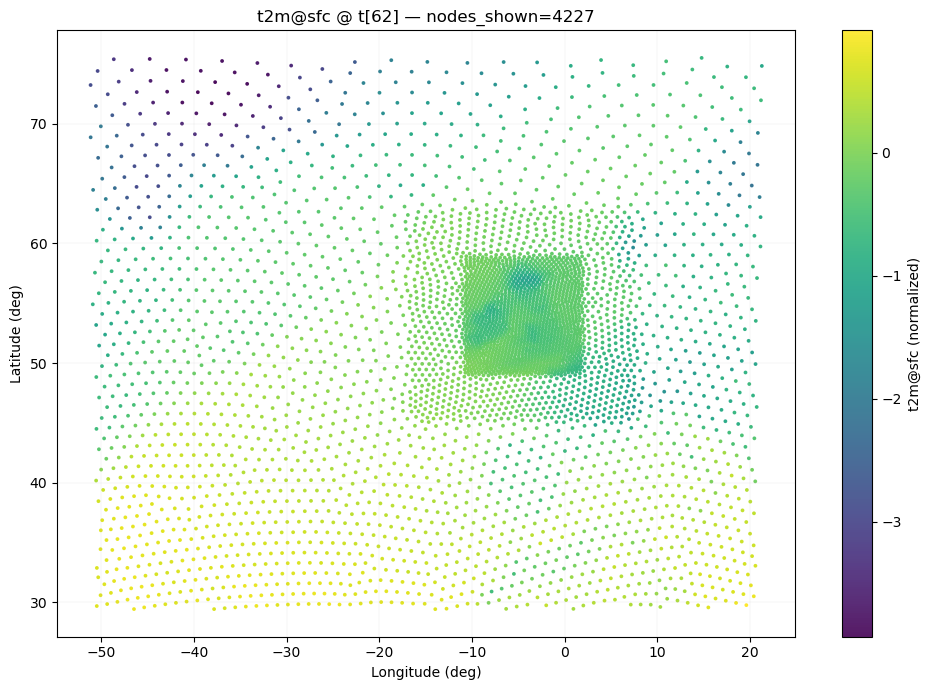

t2m@sfc @ t[62]  min=-3.9336  max=0.9961  mean=-0.2664  std=0.6558


In [13]:
# -- знайти індекс каналу
target_ch = f"{SELECT_VAR}@{SELECT_LEVEL}"
if target_ch not in channels:
    raise ValueError(f"Channel '{target_ch}' not found. Available examples: {channels[:8]} ...")
ci = channels.index(target_ch)

# -- вибрати часовий зріз
T = sh["T"]; vals = sh["values"]
t_idx = (T // 2) if TIME_INDEX is None else int(TIME_INDEX)
if not (0 <= t_idx < T):
    raise IndexError(f"TIME_INDEX out of range [0..{T-1}]")
field = vals[t_idx, ci, :]  # [N_mesh]

# -- координати вузлів
lon, lat = load_static_graph_coords(STATIC_GRAPH_NPZ)
if lon.shape[0] != sh["N_mesh"]:
    # якщо у статиці збережено координати тільки для базового шару (що і потрібно),
    # вони вже відповідають N_mesh
    pass

# -- підсемплювання вузлів
idx = np.arange(sh["N_mesh"], dtype=np.int32)
if idx.size > MAX_NODES_PLOT:
    rng = np.random.default_rng(0)
    idx = np.sort(rng.choice(idx, size=MAX_NODES_PLOT, replace=False))

# -- малюємо
plt.figure(figsize=(10, 7))
sc = plt.scatter(lon[idx], lat[idx], s=POINT_SIZE, alpha=ALPHA_POINTS, c=field[idx])
plt.colorbar(sc, label=f"{target_ch} (normalized)")
plt.title(f"{target_ch} @ t[{t_idx}] — nodes_shown={idx.size}")
plt.xlabel("Longitude (deg)"); plt.ylabel("Latitude (deg)")
plt.grid(True, linewidth=0.3, alpha=0.3)
plt.tight_layout(); plt.show()

# Додаткові швидкі stats по обраному зрізу:
print(f"{target_ch} @ t[{t_idx}]  min={float(np.nanmin(field)):.4f}  "
      f"max={float(np.nanmax(field)):.4f}  mean={float(np.nanmean(field)):.4f}  "
      f"std={float(np.nanstd(field)):.4f}")